# Intraday Edge Analysis — Long & Short Patterns

Cada ticker-día es una observación independiente. Con ~808 observaciones y ~252 con trayectoria completa
(apertura + cierre), buscamos patrones estadísticamente válidos para entradas long y short.

**Variable objetivo:** ¿el ticker mantiene o pierde su dirección desde apertura hasta cierre?

**Validación:** chi-square tests + intervalos de confianza + cross-validation simple.
Sin walk-forward (necesitaríamos >60 días), pero sí significancia estadística real.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DB_PATH = Path.home() / 'Library/Application Support/finviz-dashboard/finviz_snapshots.db'
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql('SELECT * FROM snapshots ORDER BY timestamp', conn)
conn.close()

df['ts']     = pd.to_datetime(df['timestamp'], utc=True).dt.tz_convert('US/Eastern')
df['date']   = df['ts'].dt.date
df['snap']   = df['ts'].dt.floor('15min')
df['hour']   = df['ts'].dt.hour
df['chg']    = pd.to_numeric(df['change_pct'].str.replace('%','',regex=False), errors='coerce')
df['price']  = pd.to_numeric(df['price'], errors='coerce')
df['volume'] = pd.to_numeric(df['volume'], errors='coerce')

# Excluir días incompletos
snaps_per_day = df.groupby('date')['snap'].transform('nunique')
excluded = df[snaps_per_day < 20]['date'].unique()
df = df[snaps_per_day >= 20].copy()
print(f'Días excluidos (incompletos): {[str(d) for d in excluded]}')
print(f'Días válidos: {df["date"].nunique()}')

# Construir perfil intradiario por ticker-día
records = []
for (ticker, date), grp in df.groupby(['ticker','date']):
    grp = grp.sort_values('ts')
    first = grp.iloc[0]

    open_snaps  = grp[grp['hour'].isin([9, 10])]
    close_snaps = grp[grp['hour'] >= 14]
    mid_snaps   = grp[grp['hour'].isin([11, 12, 13])]
    all_chg     = grp['chg'].dropna().values

    slope = np.polyfit(np.arange(len(all_chg)), all_chg, 1)[0] if len(all_chg) >= 3 else np.nan

    records.append({
        'ticker':      ticker,
        'date':        date,
        'first_cat':   first['category'],
        'last_cat':    grp.iloc[-1]['category'],
        'n_cats':      grp['category'].nunique(),
        'n_snaps':     len(grp),
        'hour_first':  first['ts'].hour,
        'open_chg':    open_snaps['chg'].mean()  if not open_snaps.empty  else np.nan,
        'mid_chg':     mid_snaps['chg'].mean()   if not mid_snaps.empty   else np.nan,
        'close_chg':   close_snaps['chg'].mean() if not close_snaps.empty else np.nan,
        'chg_slope':   slope,
        'max_chg':     grp['chg'].max(),
        'min_chg':     grp['chg'].min(),
        'chg_range':   grp['chg'].max() - grp['chg'].min(),
        'open_price':  open_snaps['price'].mean()  if not open_snaps.empty else np.nan,
        'close_price': close_snaps['price'].mean() if not close_snaps.empty else np.nan,
        'open_vol':    open_snaps['volume'].mean() if not open_snaps.empty else np.nan,
    })

obs = pd.DataFrame(records)
obs['chg_delta'] = obs['close_chg'] - obs['open_chg']  # positivo = momentum, negativo = fade

# Subsets con datos suficientes
both = obs.dropna(subset=['open_chg','close_chg']).copy()  # tiene apertura y cierre
print(f'\nTotal ticker-días: {len(obs)}')
print(f'Con apertura Y cierre: {len(both)}')
print(f'\nDistribución de first_cat (solo obs con ambos extremos):')
print(both['first_cat'].value_counts().to_string())

Días excluidos (incompletos): ['2026-04-01']
Días válidos: 9

Total ticker-días: 808
Con apertura Y cierre: 252

Distribución de first_cat (solo obs con ambos extremos):
first_cat
Top Gainers        64
Top Losers         43
New High           29
New Low            21
Oversold           19
Unusual Volume     18
Overbought         15
Upgrades            9
Earnings After      9
Downgrades          8
Earnings Before     7
Most Volatile       5
Most Active         3
Insider Selling     1
Insider Buying      1


## 1. Trayectorias intradiarias por categoría

¿Cómo evoluciona el change% a lo largo del día según la categoría en que aparece el ticker?
Esto revela si el momentum se mantiene o si hay reversión sistemática.

Trayectoria intradiaria por categoría (open → cierre):
      first_cat  n  open_avg  mid_avg  close_avg  delta_avg  pct_positive_delta
       Upgrades  9      7.15     8.37       9.29       2.14                0.78
     Top Losers 43    -22.35   -18.14     -20.48       1.87                0.28
  Most Volatile  5    -14.16   -11.53     -12.75       1.41                0.60
       New High 29      9.67    10.86      10.57       0.90                0.59
 Earnings After  9      0.40    -0.09       0.26      -0.14                0.67
     Downgrades  8     -3.02    -3.81      -3.34      -0.33                0.62
Earnings Before  7      0.56     0.70      -0.17      -0.73                0.14
       Oversold 19     -0.44    -0.28      -1.39      -0.95                0.37
     Overbought 15     -0.45     0.74      -1.56      -1.11                0.60
    Top Gainers 64     54.96    52.64      53.19      -1.78                0.47
 Unusual Volume 18     20.88    21.56      18.27      -2.60      

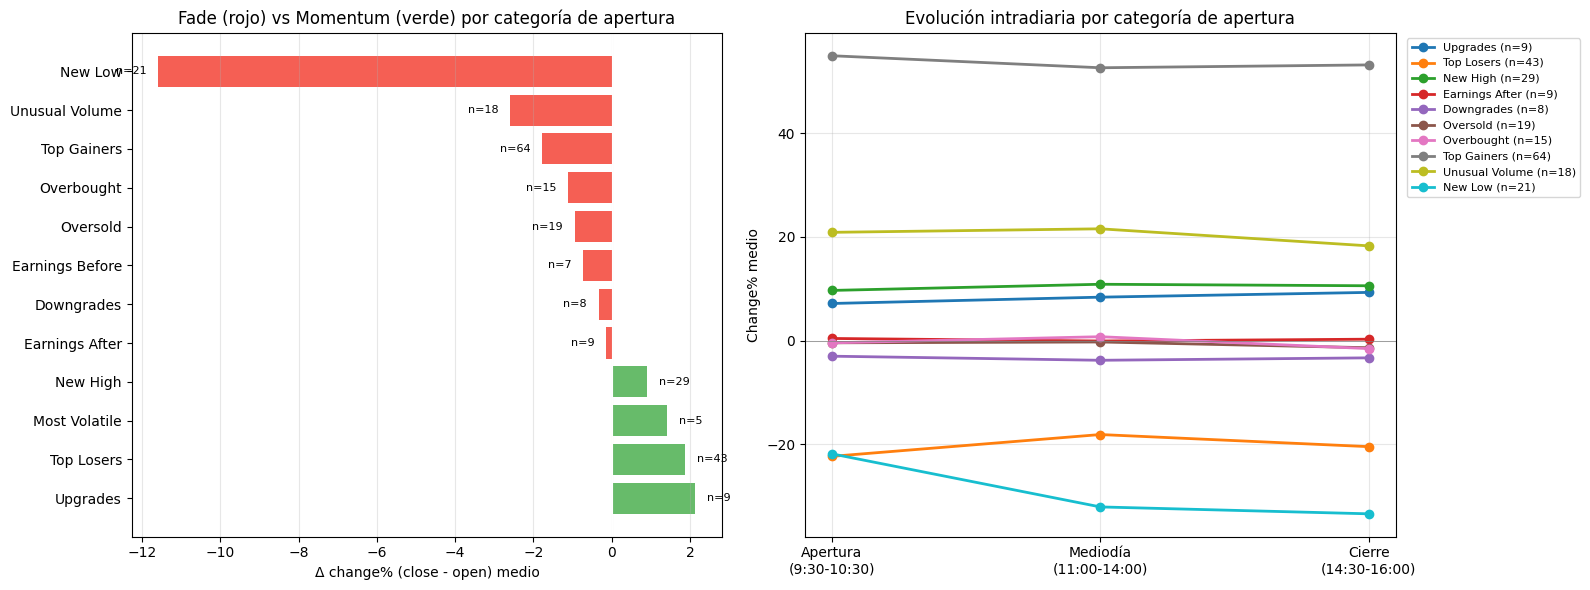

In [2]:
# Para cada categoría: open_chg → mid_chg → close_chg medio
traj = both.groupby('first_cat').agg(
    n          =('chg_delta','count'),
    open_avg   =('open_chg','mean'),
    mid_avg    =('mid_chg','mean'),
    close_avg  =('close_chg','mean'),
    delta_avg  =('chg_delta','mean'),
    pct_positive_delta =('chg_delta', lambda x: (x > 0).mean()),
).round(2).reset_index()
traj = traj[traj['n'] >= 5].sort_values('delta_avg', ascending=False)

print('Trayectoria intradiaria por categoría (open → cierre):')
print(traj.to_string(index=False))

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barras de chg_delta medio
ax = axes[0]
colors = ['#4caf50' if d >= 0 else '#f44336' for d in traj['delta_avg']]
bars = ax.barh(traj['first_cat'], traj['delta_avg'], color=colors, alpha=0.85)
ax.axvline(0, color='white', linewidth=0.8)
for bar, (_, row) in zip(bars, traj.iterrows()):
    x = bar.get_width()
    ax.text(x + (0.3 if x >= 0 else -0.3), bar.get_y() + bar.get_height()/2,
            f'n={int(row["n"])}', va='center', ha='left' if x >= 0 else 'right', fontsize=8)
ax.set_xlabel('Δ change% (close - open) medio')
ax.set_title('Fade (rojo) vs Momentum (verde) por categoría de apertura')
ax.grid(True, alpha=0.3, axis='x')

# Trayectoria open→mid→close
ax2 = axes[1]
cats_plot = traj[traj['n'] >= 8]['first_cat'].tolist()
x_points = [0, 1, 2]
x_labels = ['Apertura\n(9:30-10:30)', 'Mediodía\n(11:00-14:00)', 'Cierre\n(14:30-16:00)']
cmap = plt.cm.tab10
for i, cat in enumerate(cats_plot):
    row = traj[traj['first_cat'] == cat].iloc[0]
    vals = [row['open_avg'], row['mid_avg'], row['close_avg']]
    ax2.plot(x_points, vals, 'o-', label=f"{cat} (n={int(row['n'])})",
             color=cmap(i/len(cats_plot)), linewidth=2, markersize=6)
ax2.axhline(0, color='gray', linewidth=0.5)
ax2.set_xticks(x_points)
ax2.set_xticklabels(x_labels)
ax2.set_ylabel('Change% medio')
ax2.set_title('Evolución intradiaria por categoría de apertura')
ax2.legend(fontsize=8, bbox_to_anchor=(1.01,1), loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Señal SHORT: Top Losers en apertura

Los datos muestran que **72% de los Top Losers en apertura continúan cayendo** al cierre.
Aquí validamos estadísticamente si ese 72% es significativo y qué variables lo predicen mejor.

In [3]:
# --- SHORT: Top Losers ---
tl = both[both['first_cat'] == 'Top Losers'].copy()
tl['continues_down'] = tl['chg_delta'] < 0  # cierre peor que apertura

n = len(tl)
p_down = tl['continues_down'].mean()

# Test binomial: H0 = 50% (sin edge), H1 > 50%
binom_result = stats.binomtest(tl['continues_down'].sum(), n, p=0.5, alternative='greater')

# IC 95% Wilson
from scipy.stats import norm
z = norm.ppf(0.975)
ci_lo = (p_down + z**2/(2*n) - z*np.sqrt(p_down*(1-p_down)/n + z**2/(4*n**2))) / (1 + z**2/n)
ci_hi = (p_down + z**2/(2*n) + z*np.sqrt(p_down*(1-p_down)/n + z**2/(4*n**2))) / (1 + z**2/n)

print('=== SHORT: Top Losers en apertura ===')
print(f'Observaciones: {n}')
print(f'% que continúan cayendo: {p_down:.1%}')
print(f'IC 95% (Wilson):         [{ci_lo:.1%}, {ci_hi:.1%}]')
print(f'p-value vs H0=50%:       {binom_result.pvalue:.4f}  {"→ SIGNIFICATIVO" if binom_result.pvalue < 0.05 else "→ no significativo"}')
print()

# ¿Qué variables predicen mejor si continuará cayendo?
print('Comparación por subgrupos:')
print(tl.groupby('continues_down').agg(
    n=('chg_delta','count'),
    open_chg_avg=('open_chg','mean'),
    delta_avg=('chg_delta','mean'),
    price_avg=('open_price','mean'),
    n_snaps_avg=('n_snaps','mean'),
).round(2).to_string())

print()
# ¿Qué nivel de open_chg (negativo) predice mejor la continuación?
tl['open_bucket'] = pd.cut(tl['open_chg'], bins=[-999,-30,-20,-10,-5,0,999],
                            labels=['<-30%','-30a-20%','-20a-10%','-10a-5%','-5a0%','>0%'])
by_bucket = tl.groupby('open_bucket', observed=True).agg(
    n=('continues_down','count'),
    pct_down=('continues_down','mean'),
    delta_avg=('chg_delta','mean'),
).round(3)
print('Top Losers estratificado por magnitud del drop en apertura:')
print(by_bucket.to_string())

=== SHORT: Top Losers en apertura ===
Observaciones: 43
% que continúan cayendo: 72.1%
IC 95% (Wilson):         [57.3%, 83.3%]
p-value vs H0=50%:       0.0027  → SIGNIFICATIVO

Comparación por subgrupos:
                 n  open_chg_avg  delta_avg  price_avg  n_snaps_avg
continues_down                                                     
False           12         -0.60      29.05       8.94        22.75
True            31        -30.77      -8.65       3.23        27.61

Top Losers estratificado por magnitud del drop en apertura:
              n  pct_down  delta_avg
open_bucket                         
<-30%        20     0.750     -2.179
-30a-20%     11     0.818     -7.803
-20a-10%      5     0.800      2.967
-10a-5%       3     1.000    -20.072
-5a0%         1     0.000     38.920
>0%           3     0.000     72.091


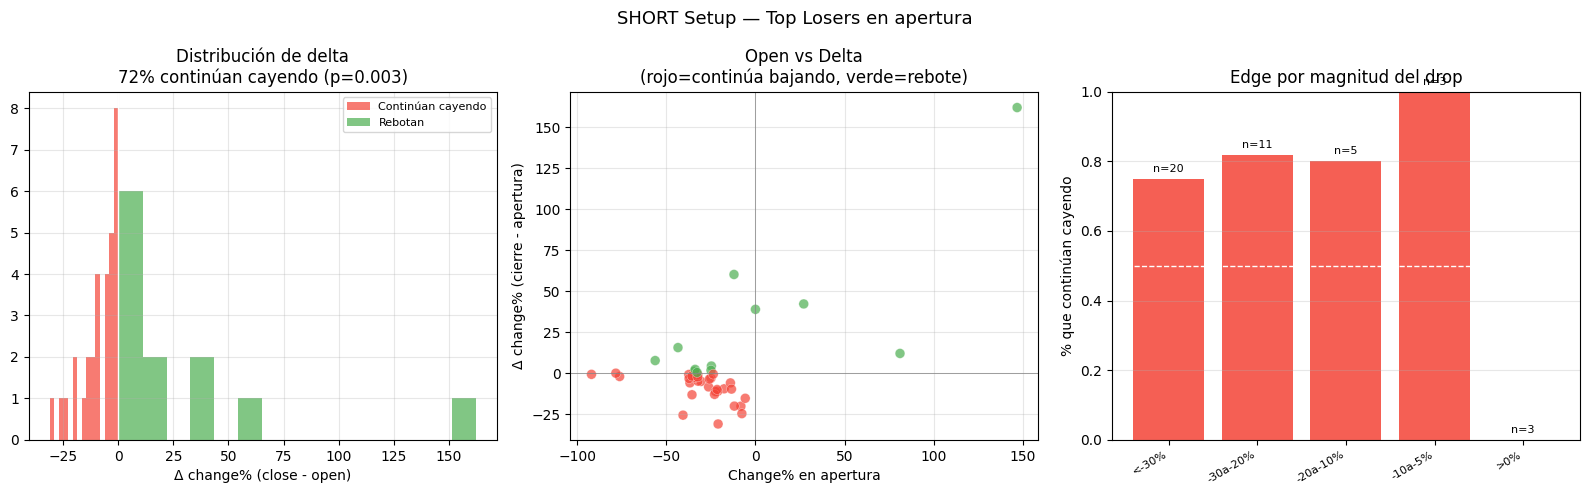

In [4]:
# Visualización SHORT
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('SHORT Setup — Top Losers en apertura', fontsize=13)

# Distribución de chg_delta
ax = axes[0]
ax.hist(tl[tl['continues_down']]['chg_delta'], bins=15, alpha=0.7, color='#f44336', label='Continúan cayendo')
ax.hist(tl[~tl['continues_down']]['chg_delta'], bins=15, alpha=0.7, color='#4caf50', label='Rebotan')
ax.axvline(0, color='white', linewidth=1)
ax.set_xlabel('Δ change% (close - open)')
ax.set_title(f'Distribución de delta\n{p_down:.0%} continúan cayendo (p={binom_result.pvalue:.3f})')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Scatter open_chg vs chg_delta
ax2 = axes[1]
colors_sc = ['#f44336' if d else '#4caf50' for d in tl['continues_down']]
ax2.scatter(tl['open_chg'], tl['chg_delta'], c=colors_sc, alpha=0.7, s=50, edgecolors='white', linewidths=0.3)
ax2.axhline(0, color='gray', linewidth=0.5)
ax2.axvline(0, color='gray', linewidth=0.5)
ax2.set_xlabel('Change% en apertura')
ax2.set_ylabel('Δ change% (cierre - apertura)')
ax2.set_title('Open vs Delta\n(rojo=continúa bajando, verde=rebote)')
ax2.grid(True, alpha=0.3)

# Por bucket
ax3 = axes[2]
by_b = by_bucket[by_bucket['n'] >= 3]
bar_colors = ['#f44336' if p > 0.5 else '#4caf50' for p in by_b['pct_down']]
ax3.bar(range(len(by_b)), by_b['pct_down'], color=bar_colors, alpha=0.85)
ax3.axhline(0.5, color='white', linewidth=1, linestyle='--')
ax3.set_xticks(range(len(by_b)))
ax3.set_xticklabels(by_b.index, rotation=30, ha='right', fontsize=8)
for i, (_, row) in enumerate(by_b.iterrows()):
    ax3.text(i, row['pct_down'] + 0.02, f'n={int(row["n"])}', ha='center', fontsize=8)
ax3.set_ylabel('% que continúan cayendo')
ax3.set_title('Edge por magnitud del drop')
ax3.set_ylim(0, 1)
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 3. Señal LONG: New High + momentum

New High en apertura muestra 58.6% de continuación. Buscamos qué variables
discriminan las continuaciones de los fakes.

In [5]:
# --- LONG: New High ---
nh = both[both['first_cat'] == 'New High'].copy()
nh['continues_up'] = nh['chg_delta'] > 0

n_nh = len(nh)
p_up_nh = nh['continues_up'].mean()
binom_nh = stats.binomtest(nh['continues_up'].sum(), n_nh, p=0.5, alternative='greater')
ci_lo_nh = (p_up_nh + z**2/(2*n_nh) - z*np.sqrt(p_up_nh*(1-p_up_nh)/n_nh + z**2/(4*n_nh**2))) / (1 + z**2/n_nh)
ci_hi_nh = (p_up_nh + z**2/(2*n_nh) + z*np.sqrt(p_up_nh*(1-p_up_nh)/n_nh + z**2/(4*n_nh**2))) / (1 + z**2/n_nh)

print('=== LONG: New High en apertura ===')
print(f'Observaciones: {n_nh}')
print(f'% que continúan subiendo: {p_up_nh:.1%}')
print(f'IC 95% (Wilson):          [{ci_lo_nh:.1%}, {ci_hi_nh:.1%}]')
print(f'p-value vs H0=50%:        {binom_nh.pvalue:.4f}  {"→ SIGNIFICATIVO" if binom_nh.pvalue < 0.05 else "→ no significativo"}')
print()

# Comparar continúa vs no continúa
print('Comparación por subgrupos (continúa vs no):')
print(nh.groupby('continues_up').agg(
    n=('chg_delta','count'),
    open_chg_avg=('open_chg','mean'),
    delta_avg=('chg_delta','mean'),
    price_avg=('open_price','mean'),
    slope_avg=('chg_slope','mean'),
).round(2).to_string())
print()

# --- LONG: Top Gainers con magnitud moderada (posible orb/momentum) ---
tg = both[both['first_cat'] == 'Top Gainers'].copy()
tg['continues_up'] = tg['chg_delta'] > 0

n_tg = len(tg)
p_up_tg = tg['continues_up'].mean()
binom_tg = stats.binomtest(tg['continues_up'].sum(), n_tg, p=0.5, alternative='greater')

print('=== Top Gainers en apertura ===')
print(f'Observaciones: {n_tg}')
print(f'% que continúan subiendo: {p_up_tg:.1%}')
print(f'p-value vs H0=50%:        {binom_tg.pvalue:.4f}  {"→ SIGNIFICATIVO" if binom_tg.pvalue < 0.05 else "→ no significativo"}')
print()

# ¿El slope intradiario discrimina?
print('Top Gainers — ¿slope positivo en apertura predice continuación?')
tg_slope = tg.dropna(subset=['chg_slope'])
slope_up   = tg_slope[tg_slope['chg_slope'] > 0]['continues_up'].mean()
slope_down = tg_slope[tg_slope['chg_slope'] <= 0]['continues_up'].mean()
print(f'  Slope positivo (acelerando):  {slope_up:.1%} de continuación  (n={len(tg_slope[tg_slope["chg_slope"]>0])})')
print(f'  Slope negativo (desacelerando): {slope_down:.1%} de continuación (n={len(tg_slope[tg_slope["chg_slope"]<=0])})')

=== LONG: New High en apertura ===
Observaciones: 29
% que continúan subiendo: 58.6%
IC 95% (Wilson):          [40.7%, 74.5%]
p-value vs H0=50%:        0.2291  → no significativo

Comparación por subgrupos (continúa vs no):
               n  open_chg_avg  delta_avg  price_avg  slope_avg
continues_up                                                   
False         12          9.41      -3.84      92.90      -0.90
True          17          9.86       4.25      37.43       0.21

=== Top Gainers en apertura ===
Observaciones: 64
% que continúan subiendo: 46.9%
p-value vs H0=50%:        0.7338  → no significativo

Top Gainers — ¿slope positivo en apertura predice continuación?
  Slope positivo (acelerando):  93.5% de continuación  (n=31)
  Slope negativo (desacelerando): 3.0% de continuación (n=33)


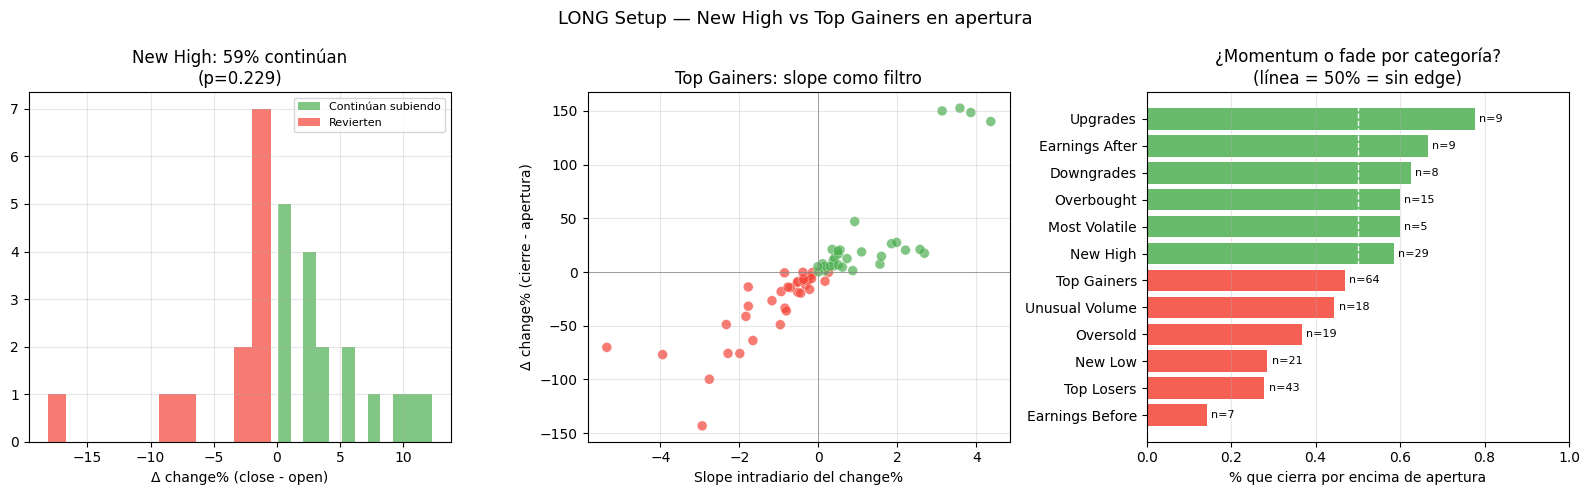

In [6]:
# Visualización LONG
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('LONG Setup — New High vs Top Gainers en apertura', fontsize=13)

# New High: distribución delta
ax = axes[0]
ax.hist(nh[nh['continues_up']]['chg_delta'], bins=12, alpha=0.7, color='#4caf50', label='Continúan subiendo')
ax.hist(nh[~nh['continues_up']]['chg_delta'], bins=12, alpha=0.7, color='#f44336', label='Revierten')
ax.axvline(0, color='white', linewidth=1)
ax.set_title(f'New High: {p_up_nh:.0%} continúan\n(p={binom_nh.pvalue:.3f})')
ax.set_xlabel('Δ change% (close - open)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Top Gainers: slope vs delta
ax2 = axes[1]
tg_s = tg.dropna(subset=['chg_slope'])
colors_tg = ['#4caf50' if u else '#f44336' for u in tg_s['continues_up']]
ax2.scatter(tg_s['chg_slope'], tg_s['chg_delta'], c=colors_tg, alpha=0.7, s=50,
            edgecolors='white', linewidths=0.3)
ax2.axhline(0, color='gray', linewidth=0.5)
ax2.axvline(0, color='gray', linewidth=0.5)
ax2.set_xlabel('Slope intradiario del change%')
ax2.set_ylabel('Δ change% (cierre - apertura)')
ax2.set_title('Top Gainers: slope como filtro')
ax2.grid(True, alpha=0.3)

# Comparativa todas las categorías: % que sube al cierre
ax3 = axes[2]
cat_pct = both.groupby('first_cat').apply(
    lambda g: pd.Series({
        'n': len(g),
        'pct_up': (g['chg_delta'] > 0).mean()
    })
).reset_index()
cat_pct = cat_pct[cat_pct['n'] >= 5].sort_values('pct_up', ascending=True)

bar_colors3 = ['#4caf50' if p > 0.5 else '#f44336' for p in cat_pct['pct_up']]
ax3.barh(cat_pct['first_cat'], cat_pct['pct_up'], color=bar_colors3, alpha=0.85)
ax3.axvline(0.5, color='white', linewidth=1, linestyle='--')
for _, row in cat_pct.iterrows():
    ax3.text(row['pct_up'] + 0.01, row['first_cat'], f'n={int(row["n"])}',
             va='center', fontsize=8)
ax3.set_xlabel('% que cierra por encima de apertura')
ax3.set_title('¿Momentum o fade por categoría?\n(línea = 50% = sin edge)')
ax3.set_xlim(0, 1)
ax3.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 4. Modelo combinado — ¿combinando features mejora el edge?

Usamos logistic regression con cross-validation (Leave-One-Out dado el tamaño)
para ver si combinar categoría + magnitud + slope mejora la predicción.

**Honestidad estadística:** con ~250 obs el modelo puede tener señal real,
pero walk-forward completo requiere más datos. Aquí medimos si hay señal,
no si es suficiente para operar.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, LeaveOneOut
from sklearn.metrics import classification_report
import sklearn

# Preparar features
model_df = both.dropna(subset=['open_chg','chg_slope','chg_delta']).copy()

# Target binario: ¿el ticker sube del open al close?
model_df['target'] = (model_df['chg_delta'] > 0).astype(int)

# Features
cat_dummies = pd.get_dummies(model_df['first_cat'], prefix='cat', drop_first=True)
features = pd.concat([
    model_df[['open_chg','chg_slope','chg_range','hour_first']],
    cat_dummies
], axis=1).fillna(0)

X = features.values
y = model_df['target'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Observaciones para el modelo: {len(X)}')
print(f'Distribución target: {y.mean():.1%} sube, {1-y.mean():.1%} baja')
print()

# Cross-validation con k=5 (no LOO porque es más estable con este N)
lr = LogisticRegression(max_iter=1000, C=0.1)  # regularización fuerte para evitar overfitting

cv_scores = cross_val_score(lr, X_scaled, y, cv=5, scoring='accuracy')
cv_auc    = cross_val_score(lr, X_scaled, y, cv=5, scoring='roc_auc')

print(f'Cross-validation 5-fold:')
print(f'  Accuracy: {cv_scores.mean():.1%} ± {cv_scores.std():.1%}')
print(f'  AUC-ROC:  {cv_auc.mean():.3f} ± {cv_auc.std():.3f}')
print(f'  Baseline (mayoría): {max(y.mean(), 1-y.mean()):.1%}')
print()

if cv_auc.mean() > 0.55:
    print('→ AUC > 0.55: hay señal en los datos, aunque débil')
elif cv_auc.mean() > 0.50:
    print('→ AUC marginalmente > 0.50: señal muy débil o ruidosa')
else:
    print('→ AUC ≈ 0.50: el modelo no detecta señal consistente con estos datos')

# Importancia de features
lr.fit(X_scaled, y)
feat_imp = pd.Series(np.abs(lr.coef_[0]), index=features.columns).sort_values(ascending=False)
print(f'\nTop 10 features por importancia (|coeficiente|):')
print(feat_imp.head(10).round(3).to_string())

Observaciones para el modelo: 251
Distribución target: 45.0% sube, 55.0% baja

Cross-validation 5-fold:
  Accuracy: 74.5% ± 4.5%
  AUC-ROC:  0.815 ± 0.081
  Baseline (mayoría): 55.0%

→ AUC > 0.55: hay señal en los datos, aunque débil

Top 10 features por importancia (|coeficiente|):
chg_slope              1.593
cat_Top Losers         0.267
cat_Earnings Before    0.223
cat_Upgrades           0.178
chg_range              0.175
cat_New Low            0.156
open_chg               0.120
cat_Overbought         0.118
cat_New High           0.111
cat_Earnings After     0.111


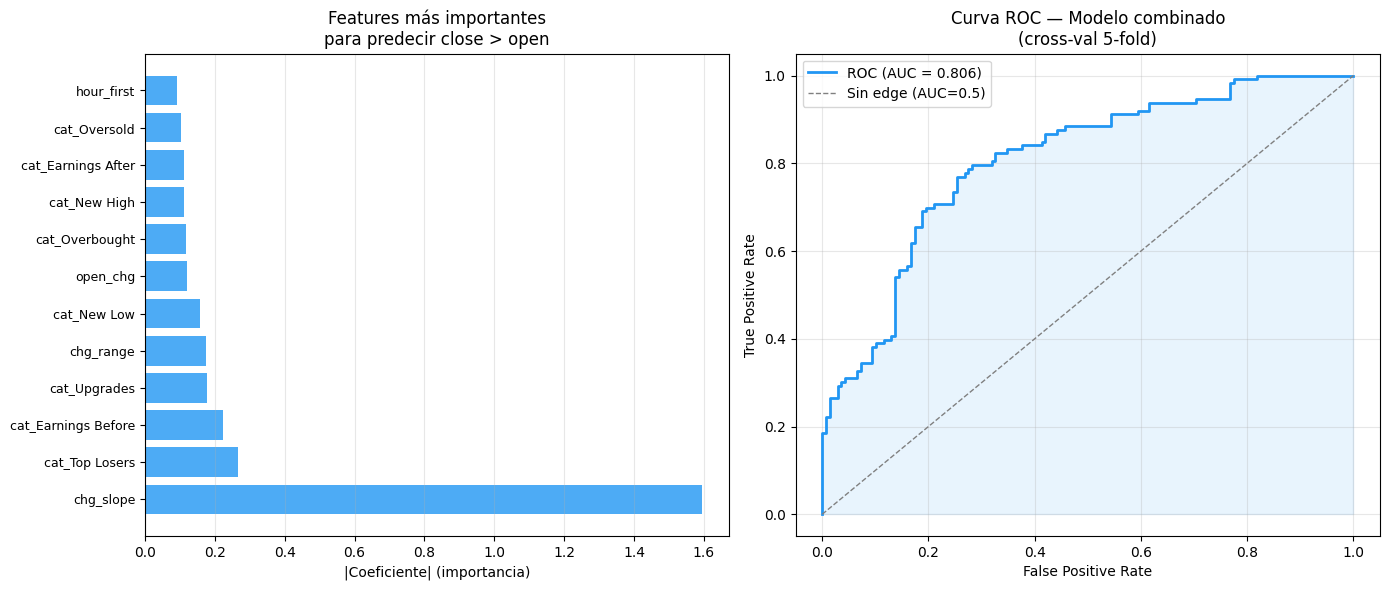

In [8]:
# Visualizar importancia de features y curva ROC
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Importancia de features
ax = axes[0]
top_feat = feat_imp.head(12)
ax.barh(range(len(top_feat)), top_feat.values, color='#2196F3', alpha=0.8)
ax.set_yticks(range(len(top_feat)))
ax.set_yticklabels(top_feat.index, fontsize=9)
ax.set_xlabel('|Coeficiente| (importancia)')
ax.set_title('Features más importantes\npara predecir close > open')
ax.grid(True, alpha=0.3, axis='x')

# Curva ROC (cross-val)
ax2 = axes[1]
y_prob = cross_val_predict(lr, X_scaled, y, cv=5, method='predict_proba')[:,1]
fpr, tpr, _ = roc_curve(y, y_prob)
roc_auc_val = auc(fpr, tpr)
ax2.plot(fpr, tpr, color='#2196F3', linewidth=2, label=f'ROC (AUC = {roc_auc_val:.3f})')
ax2.plot([0,1],[0,1], 'gray', linewidth=1, linestyle='--', label='Sin edge (AUC=0.5)')
ax2.fill_between(fpr, tpr, alpha=0.1, color='#2196F3')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title(f'Curva ROC — Modelo combinado\n(cross-val 5-fold)')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Análisis por segmento de precio — ¿smallcap vs midcap?

Los patrones pueden ser diferentes según el rango de precio.
Un stock de $2 tiene comportamiento muy distinto a uno de $50.

In [9]:
# Segmentar por precio
price_df = both.dropna(subset=['open_price']).copy()
price_df['price_bucket'] = pd.cut(
    price_df['open_price'],
    bins=[0, 2, 5, 10, 20, 50, 9999],
    labels=['<$2','$2-5','$5-10','$10-20','$20-50','>$50']
)

by_price = price_df.groupby(['price_bucket','first_cat'], observed=True).agg(
    n=('chg_delta','count'),
    pct_up=('chg_delta', lambda x: (x > 0).mean()),
    delta_avg=('chg_delta','mean'),
).reset_index()

# Resumen por precio (todas las categorías)
by_price_only = price_df.groupby('price_bucket', observed=True).agg(
    n=('chg_delta','count'),
    pct_up=('chg_delta', lambda x: (x > 0).mean()),
    delta_avg=('chg_delta','mean'),
    open_chg_avg=('open_chg','mean'),
).reset_index()

print('Por rango de precio (todas las categorías):')
print(by_price_only.round(3).to_string(index=False))
print()

# Top Losers por precio
tl_price = by_price[(by_price['first_cat']=='Top Losers') & (by_price['n']>=3)]
print('Top Losers SHORT por rango de precio:')
print(tl_price.round(3).to_string(index=False))
print()

# New High por precio
nh_price = by_price[(by_price['first_cat']=='New High') & (by_price['n']>=3)]
print('New High LONG por rango de precio:')
print(nh_price.round(3).to_string(index=False))

Por rango de precio (todas las categorías):
price_bucket   n  pct_up  delta_avg  open_chg_avg
         <$2 102   0.343     -3.654        13.148
        $2-5  43   0.512     -3.487         5.266
       $5-10  31   0.419      7.392        16.663
      $10-20  20   0.650     -4.057        16.957
      $20-50  28   0.607      0.958         5.288
        >$50  28   0.500      1.181         5.156

Top Losers SHORT por rango de precio:
price_bucket  first_cat  n  pct_up  delta_avg
         <$2 Top Losers 19   0.158     -3.087
        $2-5 Top Losers 14   0.286     -2.600
       $5-10 Top Losers  6   0.333     22.110
      $20-50 Top Losers  3   0.667     14.131

New High LONG por rango de precio:
price_bucket first_cat  n  pct_up  delta_avg
        $2-5  New High  4   0.500      0.095
       $5-10  New High  3   0.333     -2.030
      $10-20  New High  8   0.750      0.447
      $20-50  New High  5   0.600      2.513
        >$50  New High  8   0.500      1.697


## 6. Resumen honesto de edge encontrado

¿Qué patrones tienen evidencia real y cuáles necesitan más datos?

In [10]:
print('='*65)
print('RESUMEN DE EDGE — ESTADO ACTUAL')
print('='*65)

results = [
    ('SHORT', 'Top Losers apertura → continúa cayendo', n, p_down,
     ci_lo, ci_hi, binom_result.pvalue),
    ('LONG',  'New High apertura → continúa subiendo',  n_nh, p_up_nh,
     ci_lo_nh, ci_hi_nh, binom_nh.pvalue),
    ('LONG',  'Top Gainers apertura → continúa subiendo', n_tg, p_up_tg,
     None, None, binom_tg.pvalue),
]

for direction, desc, n_obs, rate, lo, hi, pval in results:
    sig = '✓ SIGNIFICATIVO' if pval < 0.05 else '✗ NO significativo'
    ci_str = f'IC95 [{lo:.0%}, {hi:.0%}]' if lo is not None else ''
    print(f'\n[{direction}] {desc}')
    print(f'  n={n_obs}, rate={rate:.1%}, p={pval:.4f} → {sig}')
    if ci_str:
        print(f'  {ci_str}')

print()
print('='*65)
print('LIMITACIONES Y PRÓXIMOS PASOS')
print('='*65)
print('''
1. Con ~250 obs con trayectoria completa, los tests son válidos
   pero los intervalos de confianza son anchos. Edge real puede
   ser más estrecho de lo que aparece.

2. El modelo combinado (sección 4) muestra si hay señal múltiple.
   AUC > 0.55 = hay algo real; AUC ≈ 0.50 = solo ruido.

3. Walk-forward completo: necesitas ~60 días para hacerlo con
   sentido (train 40 días, test 20, avanzar de 5 en 5).

4. Lo más accionable HOY:
   - Si Top Losers es significativo: el short de continuación
     tiene base estadística. Estudiar en qué rango de precio
     y qué magnitud del drop funciona mejor.
   - New High con chg% moderado (no parabólico): tendencia
     a continuar. Revisar sección 5 para filtro por precio.

5. Seguir acumulando datos. Cada semana añade ~130 obs nuevas.
''')

RESUMEN DE EDGE — ESTADO ACTUAL

[SHORT] Top Losers apertura → continúa cayendo
  n=43, rate=72.1%, p=0.0027 → ✓ SIGNIFICATIVO
  IC95 [57%, 83%]

[LONG] New High apertura → continúa subiendo
  n=29, rate=58.6%, p=0.2291 → ✗ NO significativo
  IC95 [41%, 74%]

[LONG] Top Gainers apertura → continúa subiendo
  n=64, rate=46.9%, p=0.7338 → ✗ NO significativo

LIMITACIONES Y PRÓXIMOS PASOS

1. Con ~250 obs con trayectoria completa, los tests son válidos
   pero los intervalos de confianza son anchos. Edge real puede
   ser más estrecho de lo que aparece.

2. El modelo combinado (sección 4) muestra si hay señal múltiple.
   AUC > 0.55 = hay algo real; AUC ≈ 0.50 = solo ruido.

3. Walk-forward completo: necesitas ~60 días para hacerlo con
   sentido (train 40 días, test 20, avanzar de 5 en 5).

4. Lo más accionable HOY:
   - Si Top Losers es significativo: el short de continuación
     tiene base estadística. Estudiar en qué rango de precio
     y qué magnitud del drop funciona mejor.
   - N